# Reproducible PPO–DQN HVAC Simulation Experiments

This notebook contains the executed reinforcement-learning experiments used for the comparative analysis of Proximal Policy Optimization (PPO) and Deep Q-Network (DQN) under a common HVAC simulation framework informed by IoT sensor data.

The computational workflow supports persistent per-run storage. After each scenario–seed–algorithm combination is completed, the corresponding model and evaluation outputs are written to disk so that an interrupted experiment can be resumed without repeating completed runs.

The embedded execution outputs are retained in this notebook to preserve the computational record of the completed experiment.


# Experimental Scope

## Study title

**Comparative Analysis of Proximal Policy Optimization and Deep Q-Network for HVAC Energy–Comfort Control Using IoT Data**

## Summary

The study evaluates PPO and DQN within the same discrete-action HVAC simulation using IoT-derived indoor temperature, relative humidity, recorded electrical power, occupancy, and temporal features. A fixed-threshold thermostat is included as an operational reference. The revised experimental design uses five independent training seeds and six experimental scenarios: one baseline configuration, three reward-function variants, and two local environment-parameter perturbations.

Under the baseline configuration, PPO used 18.995 ± 0.320 kWh of simulated energy and DQN used 19.505 ± 0.116 kWh. Mean comfort deviation was 0.239 ± 0.072 °C for PPO and 0.246 ± 0.069 °C for DQN. After Holm correction, the paired PPO–DQN difference was statistically significant only for simulated energy, while the differences in comfort deviation, comfort rate, and daily episode return were not significant. Sensitivity experiments further showed that the relative PPO–DQN ordering for comfort and return depends on reward formulation and simulator response parameters.

The electrical current and power measurements originate from the household electrical supply rather than a dedicated HVAC circuit. Consequently, the action-dependent power and energy quantities reported by the environment are simulation proxies and are not interpreted as direct measurements of HVAC electricity consumption.

## Experimental design

- Frameworks: `Gymnasium` and `Stable-Baselines3`
- Algorithms: PPO and DQN
- Training seeds: 42, 43, 44, 45, and 46
- Nominal training budget: 500,000 timesteps per run
- Observation vector: six normalized state components
- Action space: five discrete operating levels
- Temperature target: 24 °C
- Comfort band: 22–26 °C
- Data aggregation interval: five minutes
- Train/test split: chronological 80/20 split by retained calendar date
- Statistical analysis: mean, sample SD, 95% confidence interval, paired Wilcoxon signed-rank tests, and Holm adjustment

## Notebook structure

1. Study background
2. Sensor-data exploration
3. Data preprocessing and chronological split
4. Parameterized reinforcement-learning environment
5. Training configuration and experimental scenarios
6. Fixed-threshold reference controller
7. Evaluation and statistical analysis
8. Persistent experiment outputs
9. Reproducibility notes


In [22]:
# ==================== GOOGLE COLAB / DRIVE SETUP (ROBUST V2) ====================
from pathlib import Path
import os
import sys

IN_COLAB = 'google.colab' in sys.modules
DRIVE_MOUNTED = False

# Folder lokal selalu tersedia sebagai fallback agar notebook tidak berhenti
LOCAL_PROJECT_DIR = Path('/content/joscex_revision') if IN_COLAB else Path.cwd()
LOCAL_PROJECT_DIR.mkdir(parents=True, exist_ok=True)

if IN_COLAB:
    # Jika Drive sudah dimount manual dari panel Colab, jangan mount ulang.
    if Path('/content/drive/MyDrive').exists():
        DRIVE_MOUNTED = True
    else:
        try:
            from google.colab import drive
            drive.mount('/content/drive', force_remount=False)
            DRIVE_MOUNTED = Path('/content/drive/MyDrive').exists()
        except Exception as exc:
            # Credential-propagation error tidak boleh menghentikan seluruh notebook.
            print('PERINGATAN: Google Drive belum berhasil dimount.')
            print('Jenis error:', type(exc).__name__)
            print('Pesan:', str(exc))
            print('Notebook akan lanjut dengan fallback lokal.')
            print('Jika ingin memakai file langsung dari Drive, klik ikon Folder di kiri Colab,')
            print('pilih Mount Drive, lalu jalankan ulang cell ini.')

if IN_COLAB and DRIVE_MOUNTED:
    PROJECT_DIR = Path('/content/drive/MyDrive/JURNAL/REVISI_EKSPERIMEN_SB3')
    DATA_PATH = Path('/content/drive/MyDrive/JURNAL/EKSPERIIMEN/sensor_data.csv')
    OUTPUT_DIR = PROJECT_DIR / 'reviewer_revision_outputs'
else:
    PROJECT_DIR = LOCAL_PROJECT_DIR
    DATA_PATH = LOCAL_PROJECT_DIR / 'sensor_data.csv'
    OUTPUT_DIR = LOCAL_PROJECT_DIR / 'reviewer_revision_outputs'
    # VS Code/Jupyter lokal: taruh sensor_data.csv di working directory ini.

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR = OUTPUT_DIR / 'figures'
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

# Jika Drive gagal dimount di Colab, beri fallback upload sensor_data.csv dari komputer.
if IN_COLAB and not DATA_PATH.exists():
    print()
    print('Dataset belum ditemukan melalui Drive.')
    print('Fallback: pilih file sensor_data.csv dari komputer Anda pada dialog upload.')
    try:
        from google.colab import files as colab_files
        uploaded = colab_files.upload()
        csv_names = [name for name in uploaded.keys() if str(name).lower().endswith('.csv')]
        if not csv_names:
            raise RuntimeError('Tidak ada file CSV yang dipilih.')
        uploaded_name = csv_names[0]
        uploaded_path = Path('/content') / uploaded_name
        target_path = LOCAL_PROJECT_DIR / 'sensor_data.csv'
        if uploaded_path.resolve() != target_path.resolve():
            import shutil
            shutil.copy2(uploaded_path, target_path)
        DATA_PATH = target_path
        print('Dataset fallback siap:', DATA_PATH)
    except Exception as exc:
        raise RuntimeError(
            'Dataset tidak tersedia. Mount Google Drive secara manual atau upload sensor_data.csv, '
            f'lalu jalankan ulang cell ini. Detail: {exc}'
        ) from exc

print()
print('IN_COLAB      :', IN_COLAB)
print('DRIVE_MOUNTED:', DRIVE_MOUNTED)
print('Dataset path  :', DATA_PATH)
print('Output folder :', OUTPUT_DIR)
print('Figure folder :', FIGURE_DIR)
assert DATA_PATH.exists(), f'Dataset tidak ditemukan: {DATA_PATH}'



IN_COLAB      : False
DRIVE_MOUNTED: False
Dataset path  : d:\FILE KULIAH DOCUMENT\JURNAL\FIKKSSSSSS JOSCEXX\EKSPERIIMEN\sensor_data.csv
Output folder : d:\FILE KULIAH DOCUMENT\JURNAL\FIKKSSSSSS JOSCEXX\EKSPERIIMEN\reviewer_revision_outputs
Figure folder : d:\FILE KULIAH DOCUMENT\JURNAL\FIKKSSSSSS JOSCEXX\EKSPERIIMEN\reviewer_revision_outputs\figures


In [23]:
# Instalasi library yang diperlukan — framework tetap sama dengan eksperimen asli
!pip install stable-baselines3[extra] gymnasium pandas numpy matplotlib seaborn scikit-learn scipy -q



[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [24]:
import os
import json
import time
import random
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from scipy import stats

import gymnasium as gym
from gymnasium import spaces
from stable_baselines3 import PPO, DQN
from stable_baselines3.common.env_checker import check_env
from stable_baselines3.common.callbacks import BaseCallback
from stable_baselines3.common.utils import set_random_seed

import warnings
warnings.filterwarnings('ignore')
%matplotlib inline

try:
    plt.style.use('seaborn-v0_8-whitegrid')
except Exception:
    plt.style.use('ggplot')

plt.rcParams.update({
    'figure.figsize': (12, 6),
    'font.size': 11,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'figure.dpi': 100
})

COLORS = {'PPO': '#2196F3', 'DQN': '#9C27B0', 'Rule-Based': '#4CAF50'}

# Konfigurasi reviewer
SEEDS = [42, 43, 44, 45, 46]
SEED = SEEDS[0]  # kompatibilitas dengan bagian lama
TOTAL_TIMESTEPS = 500_000
RUN_SMOKE_TEST = False
RUN_FULL_EXPERIMENTS = True
SMOKE_PPO_TIMESTEPS = 2_048
SMOKE_DQN_TIMESTEPS = 2_000
RESUME_IF_AVAILABLE = True
OUTPUT_DIR = globals().get('OUTPUT_DIR', Path('reviewer_revision_outputs'))
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


def set_all_seeds(seed):
    os.environ['PYTHONHASHSEED'] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    set_random_seed(seed)

set_all_seeds(SEED)
print('Library berhasil dimuat.')
print('Seeds reviewer:', SEEDS)
print('RUN_SMOKE_TEST:', RUN_SMOKE_TEST)
print('RUN_FULL_EXPERIMENTS:', RUN_FULL_EXPERIMENTS)
print('RESUME_IF_AVAILABLE:', RESUME_IF_AVAILABLE)


Library berhasil dimuat.
Seeds reviewer: [42, 43, 44, 45, 46]
RUN_SMOKE_TEST: False
RUN_FULL_EXPERIMENTS: True
RESUME_IF_AVAILABLE: True


## 1. Study Background

HVAC control involves a trade-off between thermal target tracking and energy use. Reinforcement learning provides a data-driven framework for evaluating sequential control policies under explicitly defined state, action, reward, and transition models.

This study compares two commonly used reinforcement-learning algorithms under identical simulation conditions:

1. **Proximal Policy Optimization (PPO)**, an on-policy policy-gradient method that constrains policy updates through a clipped surrogate objective.
2. **Deep Q-Network (DQN)**, a value-based method that estimates action values using a neural network together with experience replay and a target network.

A deterministic fixed-threshold thermostat is evaluated as an operational reference. It is not treated as an objective-aligned competitor because it does not optimize the same reward function as PPO and DQN.

### Baseline experimental parameters

| Parameter | Value |
|---|---|
| Target temperature | 24 °C |
| Comfort band | 22–26 °C |
| Nominal training budget | 500,000 timesteps per run |
| Training seeds | 42, 43, 44, 45, 46 |
| Chronological train/test split | 80% / 20% by retained date |
| Data aggregation interval | 5 minutes |


## 2. Sensor Data Exploration

The IoT dataset was collected through a Raspberry Pi gateway and contains timestamped measurements of indoor temperature, relative humidity, voltage, current, recorded electrical power, and occupancy. The electrical measurements describe the household electrical supply and are not dedicated measurements of HVAC power consumption.

Exploratory analysis is used to characterize variable distributions, temporal behavior, and pairwise relationships before the data are transformed into the reinforcement-learning observation sequence.


In [25]:
# ==================== MEMUAT DATASET ====================
DATA_PATH = globals().get('DATA_PATH', Path('sensor_data.csv'))
df = pd.read_csv(DATA_PATH)

# Konversi kolom Timestamp ke format datetime
df['Timestamp'] = pd.to_datetime(df['Timestamp'])
df = df.sort_values('Timestamp').reset_index(drop=True)

print('=' * 65)
print('INFORMASI DATASET SENSOR HVAC')
print('=' * 65)
print(f'Jumlah observasi       : {df.shape[0]:,} baris')
print(f'Jumlah variabel        : {df.shape[1]} kolom')
print(f'Kolom                  : {list(df.columns)}')
print(f'Rentang waktu          : {df["Timestamp"].min()} s/d {df["Timestamp"].max()}')
print(f'Durasi pengumpulan     : {(df["Timestamp"].max() - df["Timestamp"].min()).days} hari')
print(f'Device ID              : {df["DeviceID"].unique()[0]}')
print(f'Total missing values   : {df.isnull().sum().sum()}')

print('\n' + '=' * 65)
print('STATISTIK DESKRIPTIF')
print('=' * 65)
df.describe().round(2)

INFORMASI DATASET SENSOR HVAC
Jumlah observasi       : 2,027,520 baris
Jumlah variabel        : 8 kolom
Kolom                  : ['Timestamp', 'DeviceID', 'Suhu (C)', 'Kelembaban (%)', 'Tegangan (V)', 'Arus (A)', 'Daya (W)', 'Jumlah Orang']
Rentang waktu          : 2026-02-23 23:14:43.896301 s/d 2026-05-24 01:22:06.727676
Durasi pengumpulan     : 89 hari
Device ID              : RASPBERRY_PI_GATEWAY_001
Total missing values   : 0

STATISTIK DESKRIPTIF


,Timestamp,Suhu (C),Kelembaban (%),Tegangan (V),Arus (A),Daya (W),Jumlah Orang
count,2027520,2027520.00,2027520.00,2027520.00,2027520.00,2027520.00,2027520.00
mean,2026-04-09 12:52:19.014636,30.19,66.63,227.04,0.16,36.93,3.08
min,2026-02-23 23:14:43.896301,26.00,47.00,197.80,0.12,25.40,0.00
25%,2026-03-18 06:23:39.557326,28.80,64.00,222.50,0.16,35.10,2.00
50%,2026-04-09 12:18:25.311988,30.50,69.00,227.50,0.16,36.80,3.00
75%,2026-05-01 19:27:20.923491,31.60,73.00,232.00,0.17,38.80,4.00
max,2026-05-24 01:22:06.727676,33.90,82.00,250.90,2.20,484.00,5.00
std,NaN,1.85,8.45,7.26,0.01,3.08,1.39


### 2.1 Sensor-Variable Distributions

The following visualizations summarize the empirical distributions of the recorded sensor variables and provide an overview of their ranges and concentration across the observation period.


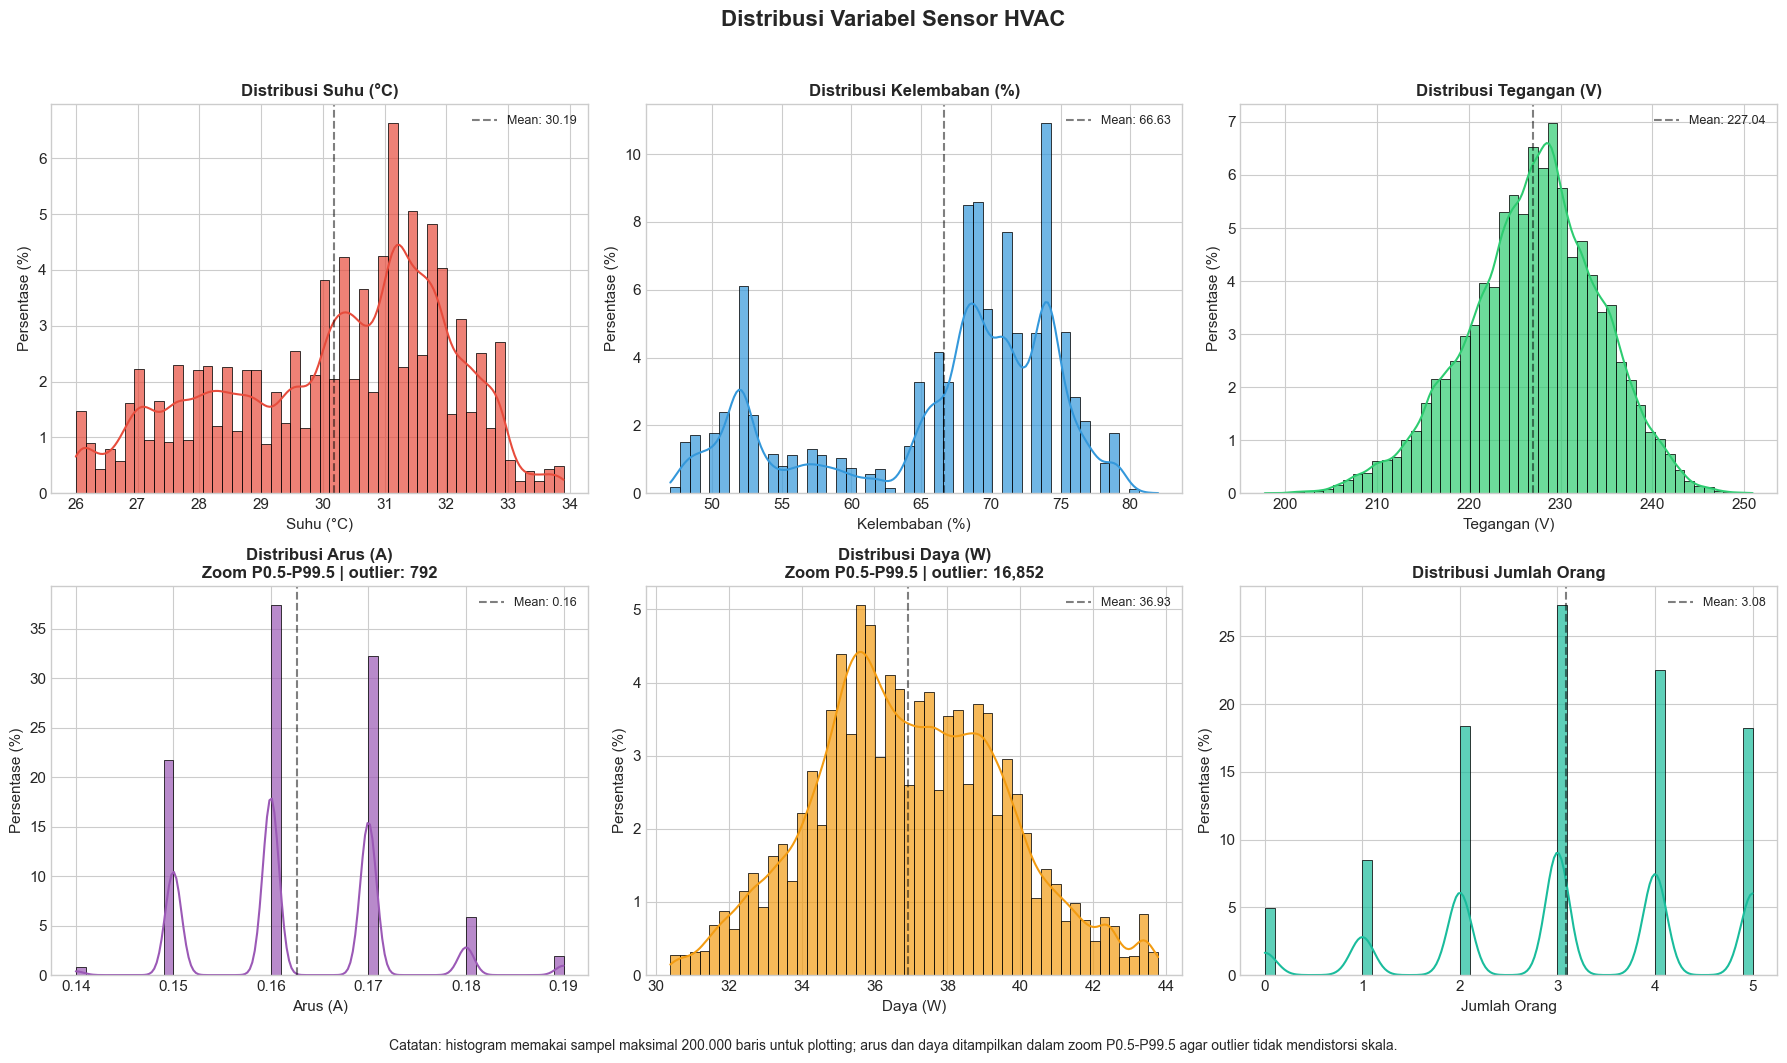

Gambar 1: Distribusi variabel sensor berhasil divisualisasikan.


In [26]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Distribusi Variabel Sensor HVAC', fontsize=16, fontweight='bold', y=1.02)

features_plot = {
    'Suhu (C)': ('Suhu (°C)', '#e74c3c'),
    'Kelembaban (%)': ('Kelembaban (%)', '#3498db'),
    'Tegangan (V)': ('Tegangan (V)', '#2ecc71'),
    'Arus (A)': ('Arus (A)', '#9b59b6'),
    'Daya (W)': ('Daya (W)', '#f39c12'),
    'Jumlah Orang': ('Jumlah Orang', '#1abc9c')
}

for ax, (col, (label, color)) in zip(axes.flat, features_plot.items()):
    plot_data = df[col].dropna()
    title_suffix = ''
    if col in ['Arus (A)', 'Daya (W)']:
        q_low, q_high = plot_data.quantile([0.005, 0.995])
        outlier_count = int(((plot_data < q_low) | (plot_data > q_high)).sum())
        plot_data = plot_data[(plot_data >= q_low) & (plot_data <= q_high)]
        title_suffix = f'\nZoom P0.5-P99.5 | outlier: {outlier_count:,}'
    plot_sample = plot_data.sample(n=min(len(plot_data), 200_000), random_state=SEED)
    sns.histplot(plot_sample, bins=50, stat='percent', kde=True, ax=ax, color=color, alpha=0.7)
    ax.set_xlabel(label, fontsize=11)
    ax.set_ylabel('Persentase (%)', fontsize=11)
    ax.set_title(f'Distribusi {label}{title_suffix}', fontsize=12, fontweight='bold')
    ax.axvline(df[col].mean(), color='black', linestyle='--', alpha=0.5, label=f'Mean: {df[col].mean():.2f}')
    ax.legend(fontsize=9)

fig.text(0.5, -0.02, 'Catatan: histogram memakai sampel maksimal 200.000 baris untuk plotting; arus dan daya ditampilkan dalam zoom P0.5-P99.5 agar outlier tidak mendistorsi skala.',
         ha='center', fontsize=10)
plt.tight_layout()
plt.savefig(FIGURE_DIR / 'distribusi_variabel.png', dpi=300, bbox_inches='tight')
plt.show()
print('Gambar 1: Distribusi variabel sensor berhasil divisualisasikan.')

### 2.2 Temporal Patterns and Correlation Analysis

Time-series inspection is used to characterize temporal variation in the sensor measurements. The correlation matrix summarizes pairwise linear associations among the recorded variables and is interpreted descriptively rather than as evidence of causation.


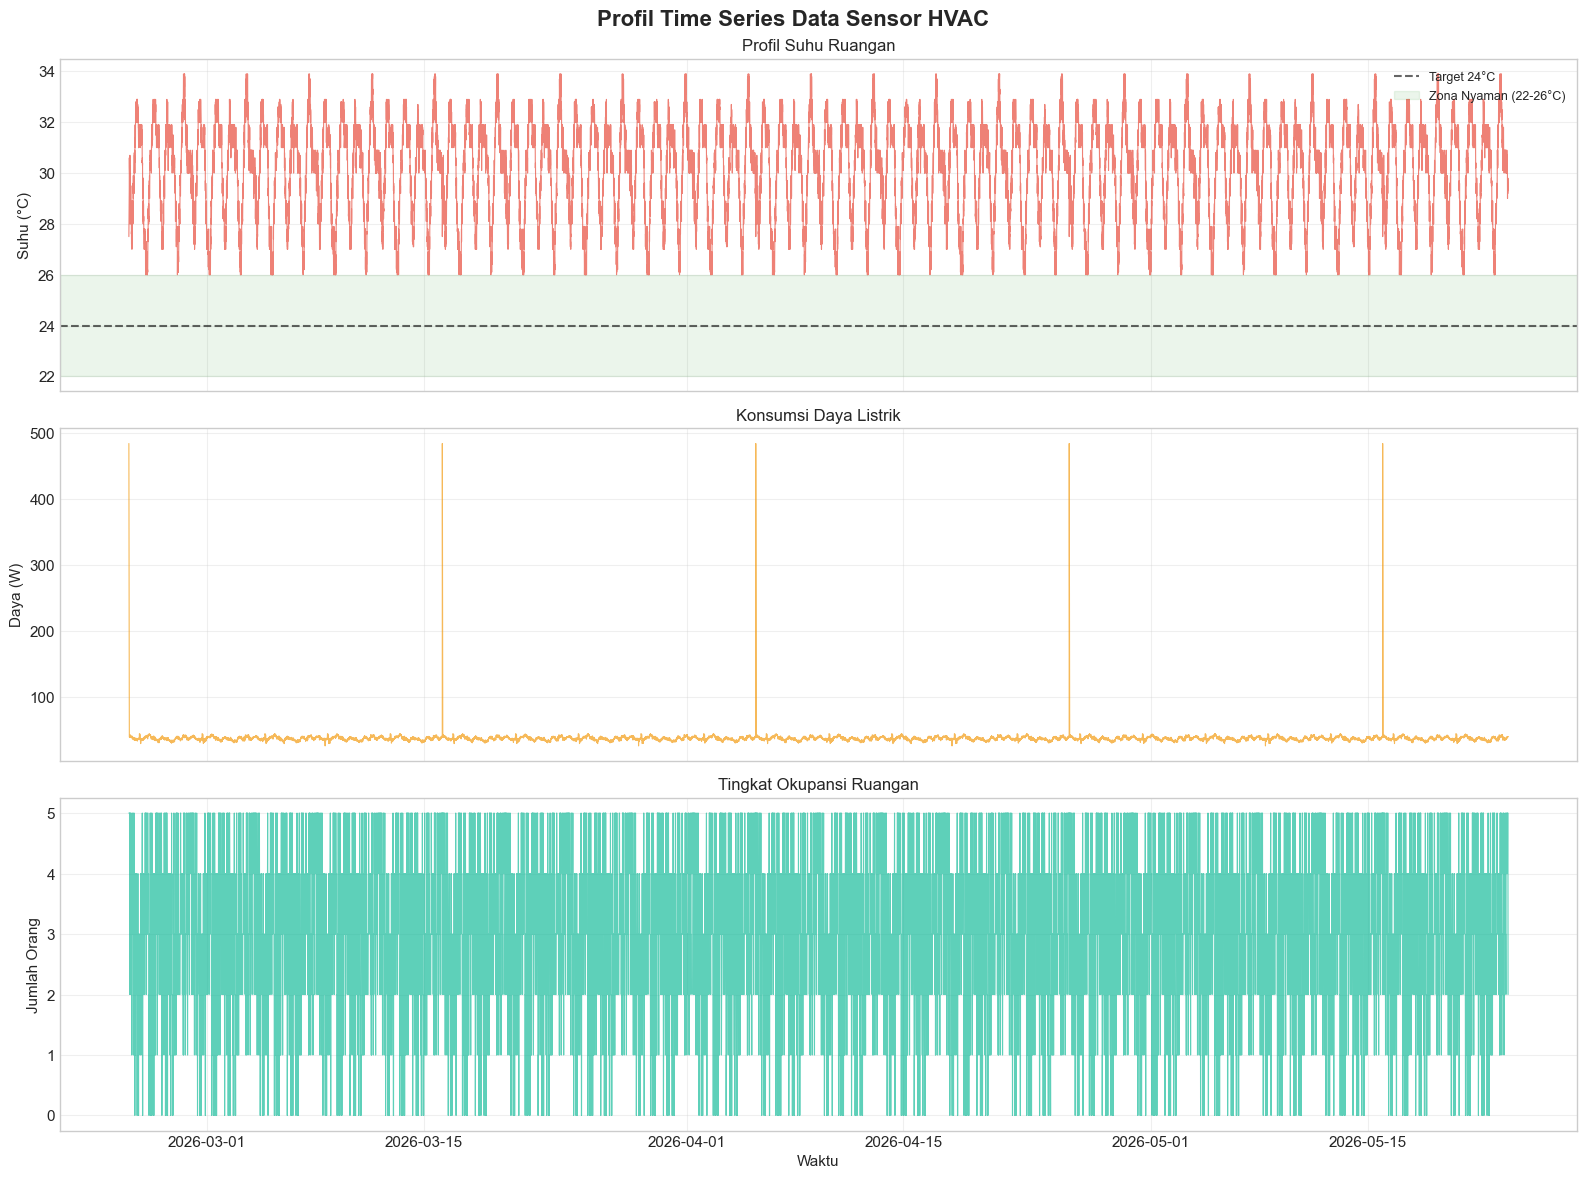

Gambar 2: Profil time series sensor berhasil divisualisasikan.


In [27]:
# ==================== TIME SERIES PLOT ====================
fig, axes = plt.subplots(3, 1, figsize=(16, 12), sharex=True)
fig.suptitle('Profil Time Series Data Sensor HVAC', fontsize=16, fontweight='bold')

# Sampling untuk efisiensi plotting (setiap titik ke-100)
sample_df = df.iloc[::100].copy()

# Plot Suhu
axes[0].plot(sample_df['Timestamp'], sample_df['Suhu (C)'], color='#e74c3c', alpha=0.7, linewidth=0.8)
axes[0].axhline(y=24, color='black', linestyle='--', alpha=0.6, linewidth=1.5, label='Target 24°C')
axes[0].axhspan(22, 26, alpha=0.08, color='green', label='Zona Nyaman (22-26°C)')
axes[0].set_ylabel('Suhu (°C)', fontsize=11)
axes[0].set_title('Profil Suhu Ruangan', fontsize=12)
axes[0].legend(loc='upper right', fontsize=9)
axes[0].grid(True, alpha=0.3)

# Plot Daya
axes[1].plot(sample_df['Timestamp'], sample_df['Daya (W)'], color='#f39c12', alpha=0.7, linewidth=0.8)
axes[1].set_ylabel('Daya (W)', fontsize=11)
axes[1].set_title('Konsumsi Daya Listrik', fontsize=12)
axes[1].grid(True, alpha=0.3)

# Plot Okupansi
axes[2].plot(sample_df['Timestamp'], sample_df['Jumlah Orang'], color='#1abc9c', alpha=0.7, linewidth=0.8)
axes[2].set_ylabel('Jumlah Orang', fontsize=11)
axes[2].set_title('Tingkat Okupansi Ruangan', fontsize=12)
axes[2].set_xlabel('Waktu', fontsize=11)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURE_DIR / 'time_series_sensor.png', dpi=300, bbox_inches='tight')
plt.show()
print('Gambar 2: Profil time series sensor berhasil divisualisasikan.')

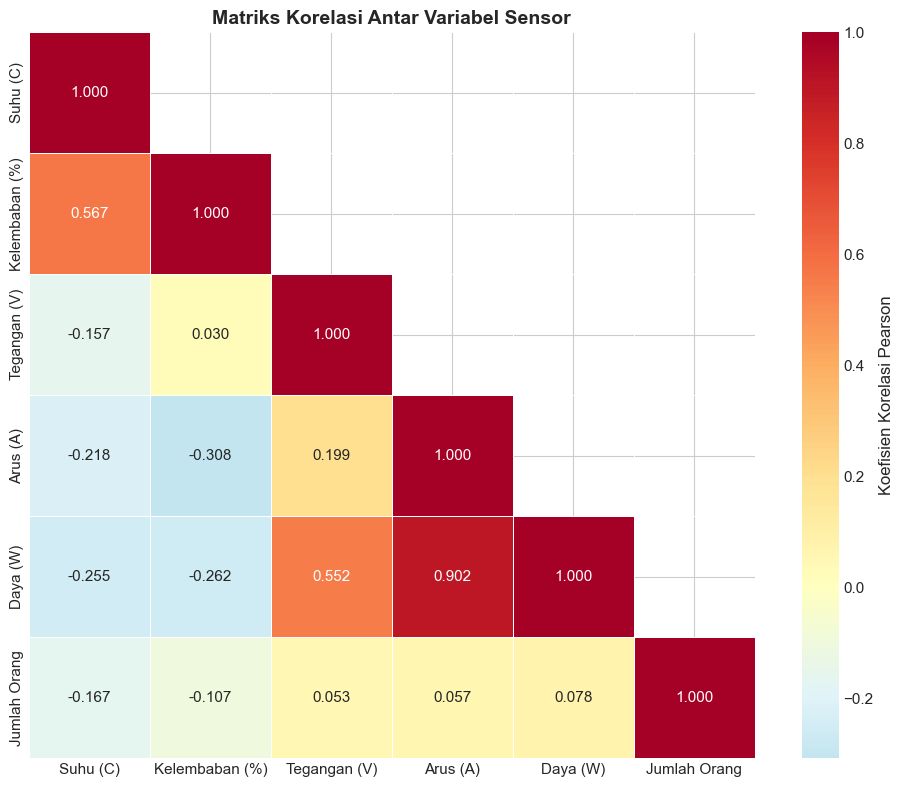

Gambar 3: Matriks korelasi berhasil divisualisasikan.


In [28]:
# ==================== MATRIKS KORELASI ====================
fig, ax = plt.subplots(figsize=(10, 8))

corr_cols = ['Suhu (C)', 'Kelembaban (%)', 'Tegangan (V)', 'Arus (A)', 'Daya (W)', 'Jumlah Orang']
corr_matrix = df[corr_cols].corr()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='RdYlBu_r',
            center=0, square=True, linewidths=0.5, ax=ax,
            mask=mask, cbar_kws={'label': 'Koefisien Korelasi Pearson'})
ax.set_title('Matriks Korelasi Antar Variabel Sensor', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig(FIGURE_DIR / 'korelasi_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()
print('Gambar 3: Matriks korelasi berhasil divisualisasikan.')

## 3. Data Preprocessing and Chronological Split

Sensor observations are aggregated into five-minute intervals. Temporal features are derived from the timestamps, and retained calendar dates are ordered chronologically before the training and test subsets are defined.

To prevent information leakage, the `MinMaxScaler` parameters are fitted exclusively on the training subset and are subsequently applied to the test subset without refitting. Values outside the training range are clipped to the observation-space bounds.

The retained-date rule follows the experimental preprocessing protocol and therefore preserves some dates with incomplete five-minute coverage. Coverage statistics are reported explicitly, including the difference between the 4,893 retained test steps and the 5,184 steps expected for 18 complete 24-hour days. Empty intervals are not imputed.


In [29]:
# ==================== PREPROCESSING DATA — REVISION COPY ====================
print('Memulai preprocessing revisi...')
print(f'Data mentah: {len(df):,} baris')

# 1. Agregasi ke interval 5 menit — sama dengan eksperimen asli
df_work = df.copy()
df_work['time_bin'] = df_work['Timestamp'].dt.floor('5min')

df_agg = df_work.groupby('time_bin').agg({
    'Suhu (C)': 'mean',
    'Kelembaban (%)': 'mean',
    'Tegangan (V)': 'mean',
    'Arus (A)': 'mean',
    'Daya (W)': 'mean',
    'Jumlah Orang': 'median'
}).reset_index().dropna()

print(f'Setelah agregasi 5 menit: {len(df_agg):,} interval non-kosong')

# 2. Fitur temporal
df_agg['hour'] = df_agg['time_bin'].dt.hour
df_agg['day_of_week'] = df_agg['time_bin'].dt.dayofweek
df_agg['date'] = df_agg['time_bin'].dt.date

# Aturan valid-date penelitian asli tetap dipertahankan
date_counts_before = df_agg.groupby('date').size()
valid_dates = date_counts_before[date_counts_before >= 10].index
df_agg = df_agg[df_agg['date'].isin(valid_dates)].reset_index(drop=True)

# 3. Split kronologis berdasarkan tanggal dilakukan SEBELUM fitting scaler
dates_sorted = sorted(df_agg['date'].unique())
split_idx = int(len(dates_sorted) * 0.8)
train_dates = dates_sorted[:split_idx]
test_dates = dates_sorted[split_idx:]

train_mask = df_agg['date'].isin(train_dates)
test_mask = df_agg['date'].isin(test_dates)

features_to_norm = ['Suhu (C)', 'Kelembaban (%)', 'Daya (W)', 'Jumlah Orang']
scaler = MinMaxScaler(feature_range=(0, 1), clip=True)
scaler.fit(df_agg.loc[train_mask, features_to_norm])

norm_cols = ['suhu_norm', 'kelembaban_norm', 'daya_norm', 'orang_norm']
df_agg.loc[:, norm_cols] = scaler.transform(df_agg[features_to_norm])
df_agg['hour_norm'] = df_agg['hour'] / 23.0
df_agg['dow_norm'] = df_agg['day_of_week'] / 6.0

df_train = df_agg[train_mask].reset_index(drop=True)
df_test = df_agg[test_mask].reset_index(drop=True)

# Reference power dibekukan dari TRAINING saja. Ini tetap proxy simulasi, bukan HVAC-only measurement.
POWER_REFERENCE_W = float(df_train['Daya (W)'].max())

# Audit coverage
train_counts = df_train.groupby('date').size()
test_counts = df_test.groupby('date').size()
expected_test_steps = len(test_dates) * 288
missing_test_steps = expected_test_steps - len(df_test)

print('\n' + '=' * 72)
print('RINGKASAN PREPROCESSING REVISI')
print('=' * 72)
print(f'Data mentah                : {len(df):,} baris')
print(f'Data teragregasi retained  : {len(df_agg):,} interval')
print(f'Jumlah tanggal retained    : {len(dates_sorted)}')
print(f'Training                   : {len(train_dates)} tanggal, {len(df_train):,} interval')
print(f'Testing                    : {len(test_dates)} tanggal, {len(df_test):,} interval')
print(f'Expected test jika lengkap : {expected_test_steps:,} interval')
print(f'Defisit coverage test      : {missing_test_steps:,} interval')
print(f'Power reference (train)    : {POWER_REFERENCE_W:.4f} W')
print(f'Rentang training            : {train_dates[0]} s/d {train_dates[-1]}')
print(f'Rentang testing             : {test_dates[0]} s/d {test_dates[-1]}')

print('\nCoverage test per tanggal yang tidak lengkap:')
incomplete_test = test_counts[test_counts < 288]
print(incomplete_test.to_string() if len(incomplete_test) else 'Semua tanggal testing lengkap.')

# Simpan audit agar dapat dilampirkan pada response reviewer
coverage_audit = pd.DataFrame({
    'date': dates_sorted,
    'n_intervals': [int((df_agg['date'] == d).sum()) for d in dates_sorted],
    'split': ['train' if d in set(train_dates) else 'test' for d in dates_sorted]
})
coverage_audit['expected_intervals'] = 288
coverage_audit['missing_intervals'] = 288 - coverage_audit['n_intervals']
coverage_audit.to_csv(OUTPUT_DIR / 'daily_coverage_audit.csv', index=False)

# Simpan parameter scaler untuk reproducibility
scaler_metadata = {
    'features': features_to_norm,
    'data_min_': scaler.data_min_.tolist(),
    'data_max_': scaler.data_max_.tolist(),
    'clip': True,
    'fit_scope': 'training_dates_only'
}
with open(OUTPUT_DIR / 'scaler_metadata.json', 'w') as f:
    json.dump(scaler_metadata, f, indent=2)


Memulai preprocessing revisi...
Data mentah: 2,027,520 baris
Setelah agregasi 5 menit: 25,549 interval non-kosong

RINGKASAN PREPROCESSING REVISI
Data mentah                : 2,027,520 baris
Data teragregasi retained  : 25,544 interval
Jumlah tanggal retained    : 90
Training                   : 72 tanggal, 20,651 interval
Testing                    : 18 tanggal, 4,893 interval
Expected test jika lengkap : 5,184 interval
Defisit coverage test      : 291 interval
Power reference (train)    : 64.4944 W
Rentang training            : 2026-02-24 s/d 2026-05-06
Rentang testing             : 2026-05-07 s/d 2026-05-24

Coverage test per tanggal yang tidak lengkap:
date
2026-05-07    283
2026-05-11    283
2026-05-15    283
2026-05-20    283
2026-05-24     17


## 4. Parameterized Reinforcement-Learning Environment

The environment retains the baseline experimental structure: a six-dimensional observation vector, five discrete actions, a 24 °C target, a 22–26 °C comfort band, a first-order temperature update, and an action-dependent reward.

For controlled sensitivity analysis, selected parameters are exposed through the environment constructor:

- reward coefficients `alpha`, `beta`, and `comfort_bonus`;
- thermal-response coefficients `eta_ext` and `eta_occ`;
- action-dependent `cooling_coefficients`.

The baseline values are unchanged from the main experimental configuration. The recorded `Suhu (C)` sequence represents indoor temperature and is used as an exogenous reference signal in the simulator.

Recorded electrical power is obtained from the household electrical supply rather than a dedicated HVAC circuit. The environment therefore uses a training-derived power reference as a **simulation scale**, and the resulting action-dependent power and energy metrics are treated as comparative simulation quantities rather than measured HVAC consumption.


In [30]:
class HVACEnergyEnv(gym.Env):
    """Custom Gymnasium environment; struktur dasar sama dengan eksperimen asli."""

    metadata = {'render_modes': []}
    ACTION_LABELS = {0: 'OFF', 1: 'LOW', 2: 'MEDIUM', 3: 'HIGH', 4: 'MAX'}

    def __init__(
        self,
        data,
        target_temp=24.0,
        comfort_range=(22.0, 26.0),
        alpha=1.0,
        beta=0.5,
        comfort_bonus=0.2,
        eta_ext=0.08,
        eta_occ=0.03,
        cooling_coefficients=None,
        power_multipliers=None,
        power_reference_w=None,
    ):
        super().__init__()
        self.data = data.copy()
        self.target_temp = float(target_temp)
        self.comfort_low, self.comfort_high = comfort_range

        self.dates = sorted(data['date'].unique())
        self.current_episode = 0
        self.current_step = 0

        self.action_space = spaces.Discrete(5)
        self.observation_space = spaces.Box(
            low=0.0, high=1.0, shape=(6,), dtype=np.float32
        )

        self.cooling_coefficients = np.array(
            cooling_coefficients if cooling_coefficients is not None
            else [0.0, 0.15, 0.35, 0.60, 0.90],
            dtype=float
        )
        self.power_multipliers = np.array(
            power_multipliers if power_multipliers is not None
            else [0.0, 0.25, 0.50, 0.75, 1.00],
            dtype=float
        )
        if len(self.cooling_coefficients) != 5 or len(self.power_multipliers) != 5:
            raise ValueError('Cooling coefficients and power multipliers must each contain 5 values.')

        # Proxy skala daya simulasi; dibekukan dari training bila diberikan.
        self.max_power = float(
            power_reference_w if power_reference_w is not None
            else data['Daya (W)'].max()
        )

        self.alpha = float(alpha)
        self.beta = float(beta)
        self.comfort_bonus_value = float(comfort_bonus)
        self.eta_ext = float(eta_ext)
        self.eta_occ = float(eta_occ)

        self.simulated_temp = self.target_temp
        self.episode_data = None

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        date_idx = self.current_episode % len(self.dates)
        self.current_date = self.dates[date_idx]
        self.episode_data = self.data[
            self.data['date'] == self.current_date
        ].reset_index(drop=True)

        self.current_step = 0
        self.current_episode += 1
        self.simulated_temp = float(self.episode_data.iloc[0]['Suhu (C)'])
        return self._get_obs(), {}

    def _get_obs(self):
        if self.current_step >= len(self.episode_data):
            return np.zeros(6, dtype=np.float32)

        row = self.episode_data.iloc[self.current_step]
        temp_norm = np.clip((self.simulated_temp - 15.0) / 25.0, 0.0, 1.0)
        return np.array([
            temp_norm,
            float(row['kelembaban_norm']),
            float(row['daya_norm']),
            float(row['orang_norm']),
            float(row['hour_norm']),
            float(row['dow_norm'])
        ], dtype=np.float32)

    def step(self, action):
        action = int(action)
        row = self.episode_data.iloc[self.current_step]

        # Nilai ini adalah suhu indoor terukur yang digunakan sebagai reference sequence.
        recorded_temp_reference = float(row['Suhu (C)'])
        occupancy = float(row['Jumlah Orang'])

        thermal_exchange = self.eta_ext * (recorded_temp_reference - self.simulated_temp)
        occupancy_heat = self.eta_occ * occupancy
        cooling = self.cooling_coefficients[action]

        self.simulated_temp += thermal_exchange + occupancy_heat - cooling
        self.simulated_temp = float(np.clip(self.simulated_temp, 15.0, 40.0))

        power_consumed = self.max_power * self.power_multipliers[action]
        temp_deviation = abs(self.simulated_temp - self.target_temp)
        power_norm = self.power_multipliers[action]

        in_comfort = self.comfort_low <= self.simulated_temp <= self.comfort_high
        bonus = self.comfort_bonus_value if in_comfort else 0.0
        reward = -self.alpha * temp_deviation - self.beta * power_norm + bonus

        self.current_step += 1
        terminated = self.current_step >= len(self.episode_data)
        truncated = False

        info = {
            'date': self.current_date,
            'temperature': self.simulated_temp,
            'power_consumed': float(power_consumed),
            'temp_deviation': float(temp_deviation),
            'in_comfort_zone': bool(in_comfort),
            'action_label': self.ACTION_LABELS[action]
        }
        return self._get_obs(), float(reward), terminated, truncated, info

print('Class HVACEnergyEnv revisi berhasil didefinisikan.')


Class HVACEnergyEnv revisi berhasil didefinisikan.


In [31]:
# ==================== VALIDASI ENVIRONMENT ====================
print('Validasi struktur environment...')
test_env = HVACEnergyEnv(df_train, power_reference_w=POWER_REFERENCE_W)
check_env(test_env, warn=True)
print('✓ Environment lolos check_env Gymnasium/SB3.')

obs, _ = test_env.reset(seed=SEED)
assert obs.shape == (6,)
assert np.isfinite(obs).all()
assert test_env.observation_space.contains(obs)

for _ in range(5):
    action = test_env.action_space.sample()
    obs, reward, terminated, truncated, info = test_env.step(action)
    assert np.isfinite(reward)
    assert test_env.observation_space.contains(obs) or terminated
    if terminated or truncated:
        break

print('✓ Smoke check step/reset environment lolos.')
print(f'Jumlah episode training: {len(test_env.dates)}')
print(f'Power reference proxy  : {test_env.max_power:.4f} W')
del test_env


Validasi struktur environment...
✓ Environment lolos check_env Gymnasium/SB3.
✓ Smoke check step/reset environment lolos.
Jumlah episode training: 72
Power reference proxy  : 64.4944 W


## 5. Training Configuration and Experimental Scenarios

Algorithm-specific hyperparameters are held fixed across all experimental scenarios. The DQN implementation uses a learning rate of **1 × 10⁻⁴**, consistent with the executed code.

| Parameter | PPO | DQN |
|---|---|---|
| Policy | MlpPolicy (64×64) | MlpPolicy (64×64) |
| Learning rate | 3 × 10⁻⁴ | **1 × 10⁻⁴** |
| Nominal training budget | 500,000 | 500,000 |
| Discount factor | 0.99 | 0.99 |
| Batch size | 64 | 32 |
| Rollout steps | 2,048 | — |
| Epochs per update | 10 | — |
| GAE lambda | 0.95 | — |
| Clip range | 0.2 | — |
| Replay buffer | — | 50,000 |
| Exploration fraction | — | 0.30 |
| Final epsilon | — | 0.10 |
| Target update interval | — | 250 |
| Train frequency | — | 4 |
| Gradient steps | — | 1 |
| Learning starts | — | 1,000 |
| Training seeds | 42, 43, 44, 45, 46 | 42, 43, 44, 45, 46 |

### Experimental scenarios

Six configurations are evaluated:

- **Baseline:** original reward and environment parameters.
- **Reward α sensitivity:** α is reduced from 1.0 to 0.5, with other parameters unchanged.
- **Reward β sensitivity:** β is increased from 0.5 to 1.0, with other parameters unchanged.
- **Comfort-bonus sensitivity:** the comfort bonus is reduced from 0.2 to 0.0.
- **Environment response ×0.8:** `eta_ext`, `eta_occ`, and all nonzero cooling coefficients are multiplied by 0.8.
- **Environment response ×1.2:** the same environment-response parameters are multiplied by 1.2.

The ±20% environment perturbations are local numerical robustness checks. They do not represent calibrated physical uncertainty bounds for the building or HVAC system.


In [32]:
class RewardLoggerCallback(BaseCallback):
    def __init__(self, verbose=0):
        super().__init__(verbose)
        self.episode_rewards = []
        self._current_reward = 0.0

    def _on_step(self):
        reward = float(self.locals.get('rewards', [0])[0])
        done = bool(self.locals.get('dones', [False])[0])
        self._current_reward += reward
        if done:
            self.episode_rewards.append(self._current_reward)
            self._current_reward = 0.0
        return True

BASE_COOLING = np.array([0.0, 0.15, 0.35, 0.60, 0.90], dtype=float)
BASE_POWER_MULT = np.array([0.0, 0.25, 0.50, 0.75, 1.00], dtype=float)

SCENARIOS = {
    'baseline': {
        'alpha': 1.0, 'beta': 0.5, 'comfort_bonus': 0.2,
        'eta_ext': 0.08, 'eta_occ': 0.03,
        'cooling_coefficients': BASE_COOLING.copy(),
    },
    'reward_alpha_0p5': {
        'alpha': 0.5, 'beta': 0.5, 'comfort_bonus': 0.2,
        'eta_ext': 0.08, 'eta_occ': 0.03,
        'cooling_coefficients': BASE_COOLING.copy(),
    },
    'reward_beta_1p0': {
        'alpha': 1.0, 'beta': 1.0, 'comfort_bonus': 0.2,
        'eta_ext': 0.08, 'eta_occ': 0.03,
        'cooling_coefficients': BASE_COOLING.copy(),
    },
    'reward_bonus_0p0': {
        'alpha': 1.0, 'beta': 0.5, 'comfort_bonus': 0.0,
        'eta_ext': 0.08, 'eta_occ': 0.03,
        'cooling_coefficients': BASE_COOLING.copy(),
    },
    'env_response_minus20': {
        'alpha': 1.0, 'beta': 0.5, 'comfort_bonus': 0.2,
        'eta_ext': 0.08 * 0.8, 'eta_occ': 0.03 * 0.8,
        'cooling_coefficients': BASE_COOLING * 0.8,
    },
    'env_response_plus20': {
        'alpha': 1.0, 'beta': 0.5, 'comfort_bonus': 0.2,
        'eta_ext': 0.08 * 1.2, 'eta_occ': 0.03 * 1.2,
        'cooling_coefficients': BASE_COOLING * 1.2,
    },
}


def make_env(data, scenario_name):
    cfg = SCENARIOS[scenario_name]
    return HVACEnergyEnv(
        data,
        alpha=cfg['alpha'],
        beta=cfg['beta'],
        comfort_bonus=cfg['comfort_bonus'],
        eta_ext=cfg['eta_ext'],
        eta_occ=cfg['eta_occ'],
        cooling_coefficients=cfg['cooling_coefficients'],
        power_multipliers=BASE_POWER_MULT,
        power_reference_w=POWER_REFERENCE_W,
    )


def build_model(algorithm, env, seed, verbose=0):
    set_all_seeds(seed)
    if algorithm == 'PPO':
        return PPO(
            'MlpPolicy', env,
            learning_rate=3e-4,
            n_steps=2048,
            batch_size=64,
            n_epochs=10,
            gamma=0.99,
            gae_lambda=0.95,
            clip_range=0.2,
            seed=seed,
            verbose=verbose,
        )
    if algorithm == 'DQN':
        return DQN(
            'MlpPolicy', env,
            learning_rate=1e-4,
            buffer_size=50_000,
            batch_size=32,
            gamma=0.99,
            exploration_fraction=0.3,
            exploration_final_eps=0.1,
            target_update_interval=250,
            train_freq=4,
            gradient_steps=1,
            learning_starts=1000,
            seed=seed,
            verbose=verbose,
        )
    raise ValueError(f'Unknown algorithm: {algorithm}')


def train_model(algorithm, scenario_name, seed, total_timesteps, save_path=None, verbose=0):
    env = make_env(df_train, scenario_name)
    callback = RewardLoggerCallback()
    model = build_model(algorithm, env, seed, verbose=verbose)
    start = time.time()
    model.learn(total_timesteps=int(total_timesteps), callback=callback, progress_bar=False)
    elapsed = time.time() - start
    completed_timesteps = int(model.num_timesteps)
    if save_path is not None:
        model.save(str(save_path))
    env.close()
    return model, callback, elapsed, completed_timesteps

print('Skenario tersedia:', list(SCENARIOS))


Skenario tersedia: ['baseline', 'reward_alpha_0p5', 'reward_beta_1p0', 'reward_bonus_0p0', 'env_response_minus20', 'env_response_plus20']


In [33]:
# ==================== SMOKE TEST TRAINING ====================
# Smoke test hanya memastikan pipeline PPO/DQN dapat berjalan; hasilnya TIDAK digunakan di manuscript.
smoke_report = []
if RUN_SMOKE_TEST:
    for algorithm, steps in [('PPO', SMOKE_PPO_TIMESTEPS), ('DQN', SMOKE_DQN_TIMESTEPS)]:
        print(f'Smoke test {algorithm}: {steps:,} timesteps...')
        model, callback, elapsed, completed = train_model(
            algorithm, 'baseline', SEED, steps, save_path=None, verbose=0
        )
        smoke_report.append({
            'algorithm': algorithm,
            'requested_timesteps': steps,
            'completed_timesteps': completed,
            'episodes_logged': len(callback.episode_rewards),
            'elapsed_s': elapsed,
        })
        # Prediksi satu episode test sebagai sanity check
        env = make_env(df_test, 'baseline')
        obs, _ = env.reset(seed=SEED)
        done = False
        n_steps = 0
        while not done:
            action, _ = model.predict(obs, deterministic=True)
            obs, reward, terminated, truncated, info = env.step(int(action))
            done = terminated or truncated
            n_steps += 1
        env.close()
        smoke_report[-1]['test_episode_steps'] = n_steps
        del model

    smoke_df = pd.DataFrame(smoke_report)
    display(smoke_df)
    smoke_df.to_csv(OUTPUT_DIR / 'smoke_test_report.csv', index=False)
    print('✓ Smoke test training selesai. Angka smoke test tidak boleh dimasukkan ke manuscript.')
else:
    print('RUN_SMOKE_TEST=False — smoke test dilewati.')


RUN_SMOKE_TEST=False — smoke test dilewati.


## 6. Fixed-Threshold Thermostat Reference

The deterministic thermostat retains the original temperature thresholds and is evaluated as a **fixed-threshold operational reference**. Because its decision rule is not optimized against the PPO/DQN reward function, its energy and comfort results are interpreted descriptively rather than as an objective-aligned reinforcement-learning benchmark.


In [34]:
class RuleBasedController:
    def __init__(self):
        self.name = 'Rule-Based Thermostat'

    def predict(self, obs, deterministic=True):
        temp = float(obs[0]) * 25.0 + 15.0
        if temp > 27.0:
            action = np.int64(4)
        elif temp > 25.0:
            action = np.int64(3)
        elif temp > 24.0:
            action = np.int64(2)
        elif temp > 23.0:
            action = np.int64(1)
        else:
            action = np.int64(0)
        return action, None

rule_based = RuleBasedController()
print('Rule-based reference didefinisikan; threshold asli dipertahankan.')


Rule-based reference didefinisikan; threshold asli dipertahankan.


## 7. Evaluation and Statistical Analysis

Each trained PPO and DQN policy is evaluated deterministically on the same 18 chronological test-date episodes. The notebook stores both aggregate metrics and date-level results for every scenario, seed, and algorithm.

The analysis reports:

- **Across five training seeds:** mean, sample standard deviation, and two-sided 95% confidence interval for each aggregate metric.
- **Paired daily comparison:** for each test date, PPO and DQN metrics are first averaged across the five training seeds and are then compared across the same 18 dates using a two-sided Wilcoxon signed-rank test.
- **Multiple-comparison control:** the four pre-specified daily outcome p-values within each scenario are adjusted using Holm's step-down procedure.

Averaging across seeds within each date before pairing avoids treating the 5 × 18 seed-date observations as 90 independent calendar days.


In [35]:
def evaluate_model_detailed(model, data, scenario_name, model_name='Model', seed=None):
    env = make_env(data, scenario_name)
    daily_rows = []
    all_temps, all_powers, all_deviations, all_comfort = [], [], [], []
    all_actions, episode_returns = [], []

    for _ in range(len(env.dates)):
        obs, _ = env.reset()
        current_date = env.current_date
        done = False
        ep_return = 0.0
        ep_temps, ep_powers, ep_devs, ep_comfort, ep_actions = [], [], [], [], []

        while not done:
            action, _ = model.predict(obs, deterministic=True)
            obs, reward, terminated, truncated, info = env.step(int(action))
            done = terminated or truncated
            ep_return += reward
            ep_temps.append(info['temperature'])
            ep_powers.append(info['power_consumed'])
            ep_devs.append(info['temp_deviation'])
            ep_comfort.append(info['in_comfort_zone'])
            ep_actions.append(int(action))

        time_interval_hours = 5.0 / 60.0
        daily_energy = float(np.sum(ep_powers) * time_interval_hours / 1000.0)
        daily_rows.append({
            'scenario': scenario_name,
            'seed': seed,
            'algorithm': model_name,
            'date': str(current_date),
            'n_steps': len(ep_powers),
            'daily_energy_kwh': daily_energy,
            'daily_comfort_deviation_c': float(np.mean(ep_devs)),
            'daily_comfort_rate_pct': float(np.mean(ep_comfort) * 100.0),
            'daily_episode_return': float(ep_return),
            'daily_peak_simulated_power_w': float(np.max(ep_powers)),
        })

        episode_returns.append(ep_return)
        all_temps.extend(ep_temps)
        all_powers.extend(ep_powers)
        all_deviations.extend(ep_devs)
        all_comfort.extend(ep_comfort)
        all_actions.extend(ep_actions)

    env.close()
    total_energy_kwh = float(np.sum(all_powers) * (5.0 / 60.0) / 1000.0)
    comfort_rate = float(np.mean(all_comfort) * 100.0)
    aggregate = {
        'total_simulated_energy_kwh': total_energy_kwh,
        'mean_comfort_deviation_c': float(np.mean(all_deviations)),
        'comfort_rate_pct': comfort_rate,
        'mean_daily_episode_return': float(np.mean(episode_returns)),
        'population_sd_daily_episode_return': float(np.std(episode_returns, ddof=0)),
        'eei_pct_points_per_kwh': float(comfort_rate / total_energy_kwh) if total_energy_kwh > 0 else np.nan,
        'peak_simulated_power_w': float(np.max(all_powers)),
        'n_test_dates': len(env.dates),
        'n_test_steps': len(all_powers),
    }
    return aggregate, pd.DataFrame(daily_rows)


In [36]:
# ==================== FULL REVIEWER EXPERIMENT — RESUMABLE V3 ====================
# 6 scenarios x 5 seeds x 2 algorithms = 60 trained models.
# Set RUN_FULL_EXPERIMENTS=True to start. Completed runs are skipped automatically.

seed_level_rows = []
daily_result_frames = []
training_rows = []

RUNS_DIR = OUTPUT_DIR / 'partial_runs'
MODEL_DIR = OUTPUT_DIR / 'models'
RUNS_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)


def _run_paths(scenario_name, seed, algorithm):
    key = f'{scenario_name}__{algorithm}__seed{seed}'
    return {
        'summary': RUNS_DIR / f'{key}__summary.json',
        'daily': RUNS_DIR / f'{key}__daily.csv',
        'training': RUNS_DIR / f'{key}__training.json',
        'model': MODEL_DIR / key,
    }


def _load_completed_run(paths):
    required = [paths['summary'], paths['daily'], paths['training']]
    if not all(p.exists() for p in required):
        return None
    with open(paths['summary'], 'r', encoding='utf-8') as f:
        summary_record = json.load(f)
    daily_df = pd.read_csv(paths['daily'])
    with open(paths['training'], 'r', encoding='utf-8') as f:
        training_record = json.load(f)
    return summary_record, daily_df, training_record


if RUN_FULL_EXPERIMENTS:
    total_jobs = len(SCENARIOS) * len(SEEDS) * 2
    job_no = 0

    for scenario_name in SCENARIOS:
        print('\n' + '=' * 88)
        print('SCENARIO:', scenario_name)
        print('=' * 88)

        for seed in SEEDS:
            for algorithm in ['PPO', 'DQN']:
                job_no += 1
                paths = _run_paths(scenario_name, seed, algorithm)

                if RESUME_IF_AVAILABLE:
                    completed_run = _load_completed_run(paths)
                    if completed_run is not None:
                        summary_record, daily_df, training_record = completed_run
                        seed_level_rows.append(summary_record)
                        daily_result_frames.append(daily_df)
                        training_rows.append(training_record)
                        print(f'[{job_no}/{total_jobs}] SKIP completed: {scenario_name} | seed={seed} | {algorithm}')
                        continue

                print(f'[{job_no}/{total_jobs}] RUN: {scenario_name} | seed={seed} | {algorithm}')
                model, callback, elapsed, completed = train_model(
                    algorithm,
                    scenario_name,
                    seed,
                    TOTAL_TIMESTEPS,
                    save_path=paths['model'],
                    verbose=0,
                )

                aggregate, daily_df = evaluate_model_detailed(
                    model, df_test, scenario_name, model_name=algorithm, seed=seed
                )

                summary_record = {
                    'scenario': scenario_name,
                    'seed': int(seed),
                    'algorithm': algorithm,
                    **aggregate,
                }
                training_record = {
                    'scenario': scenario_name,
                    'seed': int(seed),
                    'algorithm': algorithm,
                    'requested_timesteps': int(TOTAL_TIMESTEPS),
                    'completed_timesteps': int(completed),
                    'training_time_s': float(elapsed),
                    'episodes_logged': int(len(callback.episode_rewards)),
                }

                # Save immediately after each completed model/evaluation.
                with open(paths['summary'], 'w', encoding='utf-8') as f:
                    json.dump(summary_record, f, indent=2)
                daily_df.to_csv(paths['daily'], index=False)
                with open(paths['training'], 'w', encoding='utf-8') as f:
                    json.dump(training_record, f, indent=2)

                seed_level_rows.append(summary_record)
                daily_result_frames.append(daily_df)
                training_rows.append(training_record)
                print(f'    saved checkpoint/results: {paths["summary"].name}')
                del model

    seed_results = pd.DataFrame(seed_level_rows)
    daily_results = pd.concat(daily_result_frames, ignore_index=True)
    training_results = pd.DataFrame(training_rows)

    # Rule-based reference: evaluate once; no training seed is involved.
    rb_aggregate, rb_daily_results = evaluate_model_detailed(
        rule_based, df_test, 'baseline', model_name='Rule-Based', seed=None
    )
    rule_based_results = pd.DataFrame([
        {'scenario': 'baseline', 'algorithm': 'Rule-Based', **rb_aggregate}
    ])

    seed_results.to_csv(OUTPUT_DIR / 'seed_level_results.csv', index=False)
    daily_results.to_csv(OUTPUT_DIR / 'daily_results.csv', index=False)
    training_results.to_csv(OUTPUT_DIR / 'training_results.csv', index=False)
    rule_based_results.to_csv(OUTPUT_DIR / 'rule_based_baseline_results.csv', index=False)
    rb_daily_results.to_csv(OUTPUT_DIR / 'rule_based_baseline_daily.csv', index=False)
    print('\n✓ Full reviewer experiment selesai dan seluruh CSV gabungan tersimpan.')
else:
    print('RUN_FULL_EXPERIMENTS=False. Ubah ke True saat siap menjalankan eksperimen penuh.')
    print('V3 bersifat resumable: run yang sudah selesai akan dilewati saat dijalankan ulang.')



SCENARIO: baseline
[1/60] RUN: baseline | seed=42 | PPO
    saved checkpoint/results: baseline__PPO__seed42__summary.json
[2/60] RUN: baseline | seed=42 | DQN
    saved checkpoint/results: baseline__DQN__seed42__summary.json
[3/60] RUN: baseline | seed=43 | PPO
    saved checkpoint/results: baseline__PPO__seed43__summary.json
[4/60] RUN: baseline | seed=43 | DQN
    saved checkpoint/results: baseline__DQN__seed43__summary.json
[5/60] RUN: baseline | seed=44 | PPO
    saved checkpoint/results: baseline__PPO__seed44__summary.json
[6/60] RUN: baseline | seed=44 | DQN
    saved checkpoint/results: baseline__DQN__seed44__summary.json
[7/60] RUN: baseline | seed=45 | PPO
    saved checkpoint/results: baseline__PPO__seed45__summary.json
[8/60] RUN: baseline | seed=45 | DQN
    saved checkpoint/results: baseline__DQN__seed45__summary.json
[9/60] RUN: baseline | seed=46 | PPO
    saved checkpoint/results: baseline__PPO__seed46__summary.json
[10/60] RUN: baseline | seed=46 | DQN
    saved check

In [37]:
# ==================== STATISTIK MULTI-SEED & PAIRED DAILY WILCOXON ====================

def mean_sd_ci95(values):
    x = np.asarray(values, dtype=float)
    n = len(x)
    mean = float(np.mean(x))
    sd = float(np.std(x, ddof=1)) if n > 1 else np.nan
    if n > 1:
        half = float(stats.t.ppf(0.975, df=n-1) * sd / np.sqrt(n))
        return mean, sd, mean - half, mean + half
    return mean, sd, np.nan, np.nan

if RUN_FULL_EXPERIMENTS:
    metrics = [
        'total_simulated_energy_kwh',
        'mean_comfort_deviation_c',
        'comfort_rate_pct',
        'mean_daily_episode_return',
        'population_sd_daily_episode_return',
        'eei_pct_points_per_kwh',
        'peak_simulated_power_w',
    ]

    summary_rows = []
    for (scenario, algorithm), grp in seed_results.groupby(['scenario', 'algorithm']):
        for metric in metrics:
            mean, sd, ci_lo, ci_hi = mean_sd_ci95(grp[metric].values)
            summary_rows.append({
                'scenario': scenario,
                'algorithm': algorithm,
                'metric': metric,
                'n_seeds': len(grp),
                'mean': mean,
                'sd': sd,
                'ci95_low': ci_lo,
                'ci95_high': ci_hi,
            })
    multiseed_summary = pd.DataFrame(summary_rows)
    multiseed_summary.to_csv(OUTPUT_DIR / 'multiseed_summary_mean_sd_ci95.csv', index=False)

    paired_metrics = [
        'daily_energy_kwh',
        'daily_comfort_deviation_c',
        'daily_comfort_rate_pct',
        'daily_episode_return',
    ]
    test_rows = []
    for scenario in SCENARIOS:
        # Rata-rata per tanggal melintasi seed terlebih dahulu
        daily_mean = (
            daily_results[daily_results['scenario'] == scenario]
            .groupby(['date', 'algorithm'], as_index=False)[paired_metrics]
            .mean()
        )
        for metric in paired_metrics:
            pivot = daily_mean.pivot(index='date', columns='algorithm', values=metric).dropna()
            x = pivot['PPO'].values
            y = pivot['DQN'].values
            try:
                stat, p = stats.wilcoxon(x, y, alternative='two-sided', zero_method='wilcox', method='auto')
            except ValueError:
                stat, p = np.nan, np.nan
            test_rows.append({
                'scenario': scenario,
                'metric': metric,
                'n_paired_dates': len(pivot),
                'ppo_daily_mean': float(np.mean(x)),
                'dqn_daily_mean': float(np.mean(y)),
                'median_paired_difference_ppo_minus_dqn': float(np.median(x - y)),
                'wilcoxon_statistic': stat,
                'p_value_two_sided': p,
            })

    paired_tests = pd.DataFrame(test_rows)
    paired_tests.to_csv(OUTPUT_DIR / 'paired_daily_wilcoxon.csv', index=False)

    training_summary_rows = []
    for (scenario, algorithm), grp in training_results.groupby(['scenario', 'algorithm']):
        mean, sd, ci_lo, ci_hi = mean_sd_ci95(grp['training_time_s'].values)
        training_summary_rows.append({
            'scenario': scenario,
            'algorithm': algorithm,
            'n_seeds': len(grp),
            'mean_training_time_s': mean,
            'sd_training_time_s': sd,
            'ci95_low_s': ci_lo,
            'ci95_high_s': ci_hi,
            'min_training_time_s': float(grp['training_time_s'].min()),
            'max_training_time_s': float(grp['training_time_s'].max()),
            'mean_completed_timesteps': float(grp['completed_timesteps'].mean()),
        })
    training_time_summary = pd.DataFrame(training_summary_rows)
    training_time_summary.to_csv(OUTPUT_DIR / 'training_time_summary.csv', index=False)

    display(multiseed_summary)
    display(paired_tests)
    display(training_time_summary)
else:
    print('Statistik reviewer akan dihitung setelah RUN_FULL_EXPERIMENTS=True.')


,scenario,algorithm,metric,n_seeds,mean,sd,ci95_low,ci95_high
0,baseline,DQN,total_simulated_energy_kwh,5,19.504732,0.116120,19.360551,19.648914
1,baseline,DQN,mean_comfort_deviation_c,5,0.245716,0.068596,0.160542,0.330889
2,baseline,DQN,comfort_rate_pct,5,99.059881,0.000000,99.059881,99.059881
3,baseline,DQN,mean_daily_episode_return,5,-113.746462,18.996192,-137.333349,-90.159574
4,baseline,DQN,population_sd_daily_episode_return,5,22.035012,6.352109,14.147827,29.922196
...,...,...,...,...,...,...,...,...
79,reward_bonus_0p0,PPO,comfort_rate_pct,5,96.852647,2.883334,93.272515,100.432779
80,reward_bonus_0p0,PPO,mean_daily_episode_return,5,-240.909691,73.789970,-332.532040,-149.287342
81,reward_bonus_0p0,PPO,population_sd_daily_episode_return,5,58.427096,20.787170,32.616416,84.237777
82,reward_bonus_0p0,PPO,eei_pct_points_per_kwh,5,5.117907,0.184423,4.888916,5.346899


,scenario,metric,n_paired_dates,ppo_daily_mean,dqn_daily_mean,median_paired_difference_ppo_minus_dqn,wilcoxon_statistic,p_value_two_sided
0,baseline,daily_energy_kwh,18,1.055305,1.083596,-0.028082,0.0,0.000008
1,baseline,daily_comfort_deviation_c,18,0.320993,0.327466,-0.010879,68.0,0.468292
2,baseline,daily_comfort_rate_pct,18,96.883212,97.265225,0.000000,0.0,0.017960
3,baseline,daily_episode_return,18,-109.555581,-113.746462,5.171883,52.0,0.154045
4,reward_alpha_0p5,daily_energy_kwh,18,1.050498,1.065905,-0.014646,0.0,0.000196
5,reward_alpha_0p5,daily_comfort_deviation_c,18,0.295906,0.365858,-0.067153,0.0,0.000008
6,reward_alpha_0p5,daily_comfort_rate_pct,18,97.265225,97.265225,0.000000,0.0,NaN
7,reward_alpha_0p5,daily_episode_return,18,-72.797574,-84.051890,11.303258,0.0,0.000008
8,reward_beta_1p0,daily_energy_kwh,18,1.032210,1.049154,-0.017467,1.0,0.000233
9,reward_beta_1p0,daily_comfort_deviation_c,18,0.388714,0.531506,-0.148593,0.0,0.000008


,scenario,algorithm,n_seeds,mean_training_time_s,sd_training_time_s,ci95_low_s,ci95_high_s,min_training_time_s,max_training_time_s,mean_completed_timesteps
0,baseline,DQN,5,872.066291,14.928042,853.530678,890.601904,857.994745,897.060685,500000.0
1,baseline,PPO,5,1075.308263,22.853072,1046.932426,1103.684100,1060.802495,1115.814164,501760.0
2,env_response_minus20,DQN,5,810.859074,99.560796,687.238018,934.480130,757.595461,988.667526,500000.0
3,env_response_minus20,PPO,5,1137.952448,361.041588,689.660107,1586.244789,939.529199,1782.083992,501760.0
4,env_response_plus20,DQN,5,750.320787,25.228317,718.995694,781.645880,727.242948,790.955141,500000.0
5,env_response_plus20,PPO,5,962.944207,33.400744,921.471706,1004.416708,942.691687,1022.354978,501760.0
6,reward_alpha_0p5,DQN,5,852.078755,8.509014,841.513419,862.644092,844.769676,866.358054,500000.0
7,reward_alpha_0p5,PPO,5,1054.153144,10.241676,1041.436423,1066.869865,1044.949503,1067.820325,501760.0
8,reward_beta_1p0,DQN,5,863.801744,4.403767,858.333746,869.269743,859.507837,869.774240,500000.0
9,reward_beta_1p0,PPO,5,1071.390856,13.352305,1054.811780,1087.969932,1055.424501,1092.342405,501760.0


### 7.1 Interpretation of Comparative Results

The statistical outputs are interpreted according to the following principles:

- Baseline PPO–DQN comparisons are based on the five-seed summaries and paired daily tests rather than on any single training seed.
- Episode-return magnitudes are compared only within the same reward formulation because changing reward coefficients changes the numerical reward scale.
- Environment-response perturbations quantify local robustness within the specified simulator and are not interpreted as physical validation.
- The fixed-threshold thermostat is treated as an operational reference with a different control objective and is excluded from the multi-seed significance tests.
- Simulated power and energy are environment-derived proxy quantities and are not presented as measured HVAC electricity savings.


In [38]:
# ==================== TABEL RINGKAS UNTUK MANUSCRIPT ====================
if RUN_FULL_EXPERIMENTS:
    baseline_summary = multiseed_summary[multiseed_summary['scenario'] == 'baseline'].copy()
    display(baseline_summary)
    baseline_summary.to_csv(OUTPUT_DIR / 'table_baseline_multiseed_for_manuscript.csv', index=False)

    sensitivity_compact = multiseed_summary[
        multiseed_summary['metric'].isin([
            'total_simulated_energy_kwh',
            'mean_comfort_deviation_c',
            'comfort_rate_pct',
            'mean_daily_episode_return',
        ])
    ].copy()
    sensitivity_compact.to_csv(OUTPUT_DIR / 'table_sensitivity_for_manuscript.csv', index=False)
else:
    print('Tabel manuscript belum dibuat karena full experiment belum dijalankan.')


,scenario,algorithm,metric,n_seeds,mean,sd,ci95_low,ci95_high
0,baseline,DQN,total_simulated_energy_kwh,5,19.504732,0.116120,19.360551,19.648914
1,baseline,DQN,mean_comfort_deviation_c,5,0.245716,0.068596,0.160542,0.330889
2,baseline,DQN,comfort_rate_pct,5,99.059881,0.000000,99.059881,99.059881
3,baseline,DQN,mean_daily_episode_return,5,-113.746462,18.996192,-137.333349,-90.159574
4,baseline,DQN,population_sd_daily_episode_return,5,22.035012,6.352109,14.147827,29.922196
5,baseline,DQN,eei_pct_points_per_kwh,5,5.078906,0.030278,5.041310,5.116501
6,baseline,DQN,peak_simulated_power_w,5,64.494444,0.000000,64.494444,64.494444
7,baseline,PPO,total_simulated_energy_kwh,5,18.995495,0.319642,18.598607,19.392383
8,baseline,PPO,mean_comfort_deviation_c,5,0.239171,0.072254,0.149456,0.328886
9,baseline,PPO,comfort_rate_pct,5,98.655222,0.904847,97.531706,99.778737


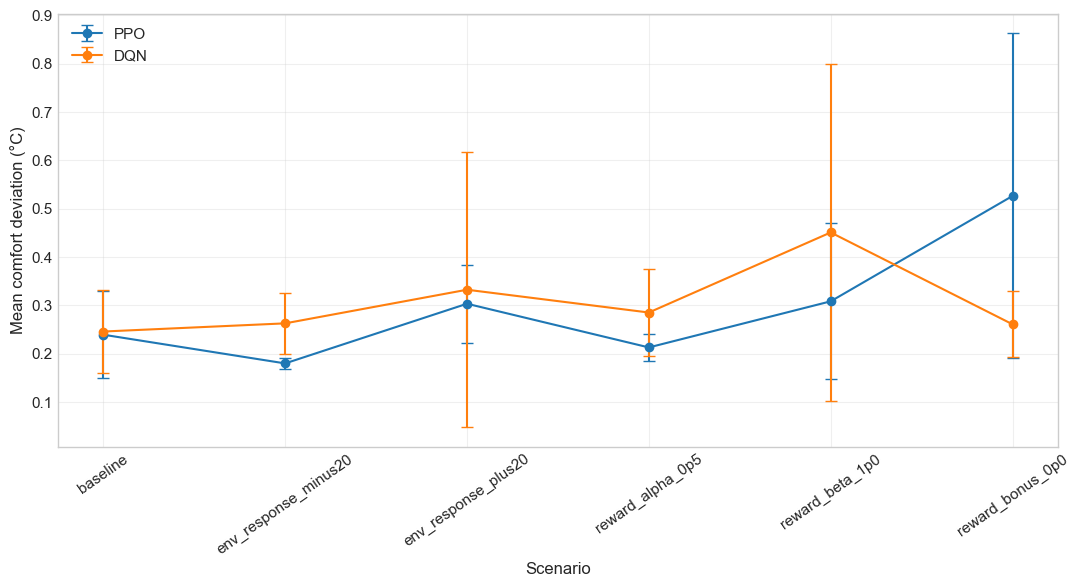

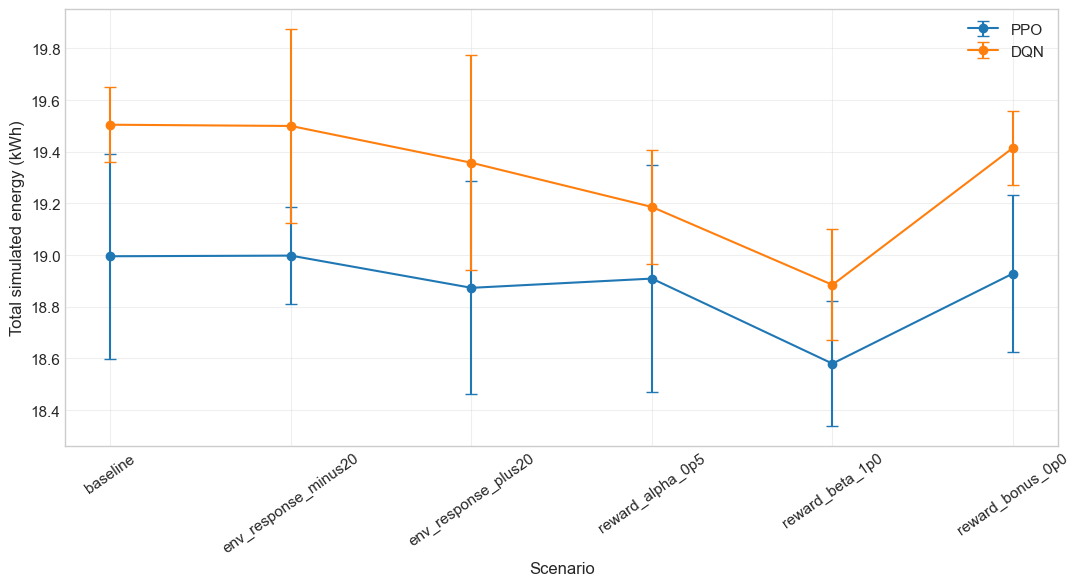

In [39]:
# ==================== FIGURE: SENSITIVITY PPO vs DQN ====================
if RUN_FULL_EXPERIMENTS:
    plot_metrics = [
        ('mean_comfort_deviation_c', 'Mean comfort deviation (°C)'),
        ('total_simulated_energy_kwh', 'Total simulated energy (kWh)'),
    ]
    for metric, ylabel in plot_metrics:
        tmp = multiseed_summary[multiseed_summary['metric'] == metric].copy()
        fig, ax = plt.subplots(figsize=(11, 6))
        for algorithm in ['PPO', 'DQN']:
            part = tmp[tmp['algorithm'] == algorithm]
            ax.errorbar(
                part['scenario'], part['mean'],
                yerr=[part['mean'] - part['ci95_low'], part['ci95_high'] - part['mean']],
                marker='o', capsize=4, label=algorithm
            )
        ax.set_ylabel(ylabel)
        ax.set_xlabel('Scenario')
        ax.tick_params(axis='x', rotation=35)
        ax.legend()
        ax.grid(True, alpha=0.3)
        plt.tight_layout()
        safe_name = metric.replace('/', '_')
        plt.savefig(OUTPUT_DIR / f'sensitivity_{safe_name}.png', dpi=300, bbox_inches='tight')
        plt.show()
else:
    print('Figure sensitivity belum dibuat karena full experiment belum dijalankan.')


## 8. Persistent Experiment Outputs

The full experiment consists of six scenarios, five training seeds, and two reinforcement-learning algorithms, yielding 60 trained PPO/DQN models. Per-run results are written to persistent storage after each completed scenario–seed–algorithm combination.

This persistence mechanism allows incomplete executions to be resumed while preserving previously completed runs. The embedded notebook outputs document the completed execution sequence and are intentionally retained as part of the computational record.


In [40]:
# ==================== VALIDASI HASIL OTOMATIS ====================
if RUN_FULL_EXPERIMENTS:
    assert set(seed_results['seed'].unique()) == set(SEEDS)
    assert set(seed_results['scenario'].unique()) == set(SCENARIOS)
    assert set(seed_results['algorithm'].unique()) == {'PPO', 'DQN'}
    assert len(seed_results) == len(SCENARIOS) * len(SEEDS) * 2
    assert daily_results['date'].nunique() == len(test_dates)
    assert (daily_results['n_steps'] > 0).all()
    assert np.isfinite(seed_results.select_dtypes(include=[np.number])).all().all()
    print('✓ Struktur hasil penuh lolos validasi otomatis.')
else:
    print('Validasi hasil penuh menunggu RUN_FULL_EXPERIMENTS=True.')


✓ Struktur hasil penuh lolos validasi otomatis.


In [41]:
# ==================== README OUTPUT EKSPERIMEN ====================
readme = f"""JOSCEX Reviewer Revision Experiment

Original framework preserved: Gymnasium + Stable-Baselines3 PPO/DQN
Dataset: sensor_data.csv
Seeds: {SEEDS}
Requested timesteps/model: {TOTAL_TIMESTEPS}
Scenarios: {list(SCENARIOS.keys())}

Important:
- Recorded current/power is general household electrical load, not HVAC-only measurement.
- Simulated power/energy are proxies generated by the environment.
- ±20% environment perturbations are local robustness probes, not calibrated uncertainty bounds.
- Reward-sensitivity comparisons should focus on policy outcomes within each reward definition.
"""
with open(OUTPUT_DIR / 'README_experiment.txt', 'w') as f:
    f.write(readme)
print(readme)


JOSCEX Reviewer Revision Experiment

Original framework preserved: Gymnasium + Stable-Baselines3 PPO/DQN
Dataset: sensor_data.csv
Seeds: [42, 43, 44, 45, 46]
Requested timesteps/model: 500000
Scenarios: ['baseline', 'reward_alpha_0p5', 'reward_beta_1p0', 'reward_bonus_0p0', 'env_response_minus20', 'env_response_plus20']

Important:
- Recorded current/power is general household electrical load, not HVAC-only measurement.
- Simulated power/energy are proxies generated by the environment.
- ±20% environment perturbations are local robustness probes, not calibrated uncertainty bounds.
- Reward-sensitivity comparisons should focus on policy outcomes within each reward definition.



In [42]:
# ==================== RINGKASAN STATUS ====================
print('Notebook revisi menggunakan SALINAN dari notebook asli.')
print('Framework/algoritma: Gymnasium + Stable-Baselines3 PPO/DQN (dipertahankan).')
print('Full experiment aktif:', RUN_FULL_EXPERIMENTS)
if RUN_FULL_EXPERIMENTS:
    print(f'Model yang dijadwalkan: {len(SCENARIOS) * len(SEEDS) * 2}')
    print('Output folder:', OUTPUT_DIR.resolve())
else:
    print('Belum ada hasil full reviewer experiment di sesi ini.')


Notebook revisi menggunakan SALINAN dari notebook asli.
Framework/algoritma: Gymnasium + Stable-Baselines3 PPO/DQN (dipertahankan).
Full experiment aktif: True
Model yang dijadwalkan: 60
Output folder: D:\FILE KULIAH DOCUMENT\JURNAL\FIKKSSSSSS JOSCEXX\EKSPERIIMEN\reviewer_revision_outputs


## 9. Reproducibility and Post-Processing

The generated artifacts include seed-level summaries, date-level evaluation records, training-time measurements, rule-based reference results, model checkpoints, and statistical output tables.

Final reported statistics are derived from the completed multi-seed experiment and the corresponding post-processing outputs. Baseline conclusions use the five-seed estimates and Holm-adjusted paired tests, while reward and environment sensitivity results are reported as separate experimental conditions.

Reproduction requires the same input dataset, five-minute aggregation procedure, chronological split, train-only normalization, simulator configuration, training seeds, Stable-Baselines3 hyperparameters, and deterministic evaluation protocol.
